# Autoencoder for Chemical Feasibility Ranking (of Intermetallic Phase Fields)

Jupyter notebook for the ranking of chemically feasible phase fields using autoencoders. Feasible candidates can be identified by proxy of similarity to a dataset of reported phase fields. The output is a list of phase fields that did not contain reported structures in the supplied dataset. Outputted phase fields are ranked by reconstruction error - a lower reconstruction error means a new phase field was able to compressed and reconstructed in the same latent space as the reported phase fields. Therefore, a lower reconstruction error means the new phase field has similar features to reported phase fields and could be more likely to be synthesisable.  

A dataset of reported compositions was extracted from the ICSD as outlined by N. L. Gulay and D. Wen et al. (2025), which was used to build the database of reported phase fields and included here. Other datasets can be used but the subsequent cells must be edited to provide the path to the dataset, the name of csv column containing compositions, and a name for the new phase field dataset. The autoencoder work is inspired by the PhaseSelect code developed by A. Vasylenko et al (2023). The method for selecting an autoencoder for subsequent one-class classification was described by C. Zhang et al. (2024).



## Necessary Imports

Below are all the necessary imports to run the subsequent code

In [1]:
import numpy as np
from numpy import nan as NaN
import pandas as pd
from DATA.ELEMENTS import ELEMENTS
from DATA.feature_labels import features
from itertools import combinations
from itertools import permutations
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing
from sklearn import datasets, metrics
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import itertools
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from math import ceil, factorial
import os
import pickle as pkl
from pathlib import Path
from data_handling import *  

2025-12-15 11:41:24.897208: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-15 11:41:26.803372: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/lib/x86_64-linux-gnu
2025-12-15 11:41:26.803410: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2025-12-15 11:41:27.057164: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-15 11:41:32.0190

In [2]:
from rank import *

In [3]:
from autoencoders import *

In [4]:
from get_candidates import *

In [5]:
from build_phasefields import *

In [6]:
from clear_files import clear

## Data Handling

The following segments generate data that is correctly formatted for the ranking. 

The order of elements in a phase field are permuted, those containing elements of atomic number > 86 are removed and features are stored from the magpie elemental feature tables. 

### Clear Files

#### This will remove files!

If a previous run has been complete in the same folder, this cell can be run to remove all files but those necessary for the code. It can be skipped if starting a completely fresh calculation in a fresh directory. 

Any files that need to be kept can be typed into the cell below in this format: clear(keep = ["file one", "file two", "file n"]). 

If files are kept, they might be overwritten later on if they are outputs. Best practice would be to move them to a separate directory. 

In [13]:
clear(keep = ["phase_field_dataset.csv"])

### Data Input 

Please input the required variables into the cell below. Some fields may or may not be required depending on the goal and input files. See the comments to determine whether each field is required for your case. If they are not required, they can be left as is.

In [7]:
### The following are only required if using a dataset of compositions, NOT phase fields ###

composition_dataset_path = "path/to/composition/dataset"  #eg. If in DATA folder, use DATA/composition_dataset
composition_dataset_path = Path(composition_dataset_path)
composition_column_name = "column_name"                   #Enter the name of the column containing the compositions in the .csv file
new_dataset_name = "new_dataset_name"                     #Enter the desired name of the new phase field dataset 

### The following is required if beginning with a dataset of phase fields. Save your phase field dataset in the DATA folder.
### If using a compositional dataset, leave blank
### Otherwise, provide the name of the phase field dataset

phase_field_dataset = "phase_field_dataset.csv"                                  #Change to the name of your phase field dataset eg. "phase_field_dataset.csv"
if not phase_field_dataset:
    phase_field_dataset = new_dataset_name

### These are required by all runs:
field_size = 3                                            #Size of phase field required eg. for ternary enter 3, quaternary 4, etc
kmin = 2                                                  #Minimum size vector to use
kmax = 16                                                 #Maximum size vector to use, these are usually fine but can be expanded
plot_his = None #True                                     #Whether to plot history of model training, change to True if needed

nrows_MFD_plot = 3                                        #These are for the nrows*ncols MFD plots for the vectors, there will always be an extra plot
ncols_MFD_plot = 5                                        #for the pure magpie vectors eg. here: 14 vectors + 1 additional gives the 15 plots specified

del_ax = None                                             #Plots can be removed if there are too many for aesthetic purposes, they are numbered 
                                                          #0 to number of plots - 1. 
                                                          #These are also fine to keep as is but can be changed if using different vector 
                                                          #ranges

### For a Compositional Dataset

Only run the below cell if using a dataset of compositions


In [9]:
df = pd.read_csv(composition_dataset_path)   ### Path to existing dataset of compositions
Compositions = df[composition_column_name]           ### Name of column with compositions
Compositions = Compositions.apply(lambda x: make_fields(x))
Compositions = get_unique(Compositions)
Compositions.to_csv(f"DATA/{new_dataset_name}")         ### Name to call the new dataset of phase fields (.csv)


### Else

All following cells, up until the last, are required for the ranking and should be run.

In [8]:
atoms = [s.strip() for s in open('DATA/magpie_tables/Abbreviation.table', 'r').readlines()]
features = features
size = field_size                                         
path = os.path.join("DATA", phase_field_dataset)                         

ground_truth, query = check_existing(atoms=atoms, size=size, path=path)

el_feats = get_elemental_features(atoms, features)

Building a new ground truth dataset...
Limiting phase fields to size 3
Checking if atoms are ok
Permuting the phase fields
Removing phase fields containing atoms with atomic number > 87
Building new query dataset...
Getting unique elements in the ground truth dataset
Constructing query phase fields
Permuting query phase fields


## Ranking

The following parts perform the actual ranking. Vectors have already been built from the magpie elemental features and range in magnitude from 1 > 20 for each element. The range included seems to work well in identifying a reasonable model for ranking, but can be expanded in the data input section if needed


In [9]:
GT_atom_inds = P2I(atoms, ground_truth)
Q_atom_inds = P2I(atoms, query)

In [10]:
main(ground_truth, query, size, el_feats=el_feats, GT_atom_inds=GT_atom_inds, Q_atom_inds=Q_atom_inds, kmin=kmin, kmax=kmax, plot_his=None)


###########################################
### Training Model with Full MP Vectors ###
###########################################
Epochs =  400


2025-12-15 11:55:06.326123: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/lib/x86_64-linux-gnu
2025-12-15 11:55:06.334968: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2025-12-15 11:55:06.335031: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (haworth): /proc/driver/nvidia/version does not exist
2025-12-15 11:55:06.336228: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
2829/2829 [==============================] - 3s 1ms/step
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please rep

## Candidate Selection

Candidates are extracted from the ranking that was determined to provide the best balance of discrimination and accuracy. Any phase field with a mean reconstruction error below the model's threshold is assigned to the feasible class and these are ranked on the reconstruction error.

Plots are generated over the range of vectors used. The chemically feasible candidates from the best model will be saved in the DATA folder, as "chemically_feasible_candidates.csv". All other rankings will also be present, from both the ground truth and query runs. 

     k       MFD  MFD Threshold       TPR       QPR  sqrt(MFD*TPR)
0  2.0  0.232929            2.8  0.793814  0.560885       0.184902
1  3.0  0.194408            8.8  0.494845  0.300438       0.096202


<Figure size 1280x960 with 0 Axes>

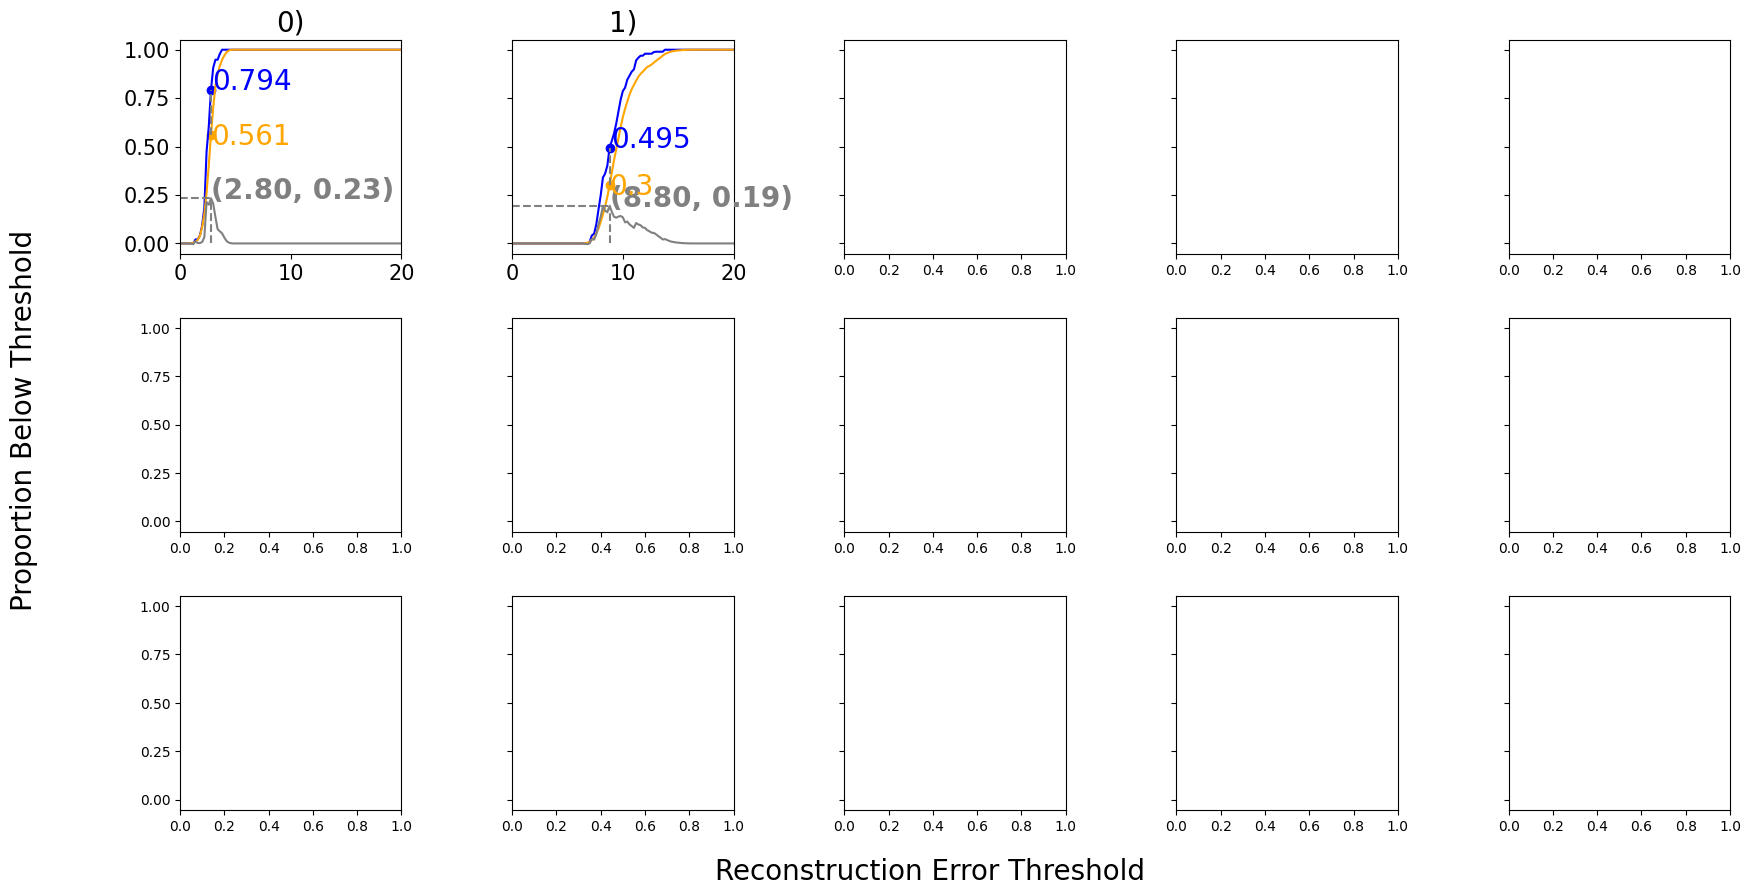

97
15083


In [11]:
vals = plot_MFD(kmin=kmin, kmax=kmax, L0=nrows_MFD_plot, L1=ncols_MFD_plot, del_ax=del_ax)

GT_means, GT_stds, GT_uni = mean_per_PF(vals[0], 
                                        size, 
                                        pd.read_csv(f"DATA/ground_truth_ranking_{vals[0]}_features.csv"))
CFC = compare_to_threshold(vals, query, size)

## Optional Analysis/Extraction

A class has been created to perform some basic analysis/extraction on the candidates. Below is a list of options for analysis:

 - get_top_n(n=number): Returns the top n ranked phase fields.
 - phase_fields_containing(atom_pool=["A", "B", "C"...]): Returns any phase fields containing one or more of atoms A, B, C...
 - phase_fields_containing_only(atom_pool=["A", "B", "C"...]: Returns phase fields containing only atoms A, B, C...

In [13]:
Results = ResultsAnalysis(CFC)

### Uncomment the desired tool by removing the hashtag at the start, and also uncomment the corresponding "print" to see the results. If a tool
### is no longer required, it can be commented out again by adding a hashtag at the start. 
### The values can be entered below. If some aren't needed, they can be left as is.

top = x                                           ### Enter how many of the top phase fields to retrieve
atom_pool1 = []                                   ### Pool of atoms for phase_fields_containing in the same format as the text above
atom_pool2 = []                                   ### Pool of atoms for phase_fields_containing_only in the same format as the text above

#top = Results.get_top_n(n=top)
#containing = Results.phase_fields_containing(atom_pool=atom_pool1)
#containing_only = Results.phase_fields_containing_only(atom_pool=atom_pool2)

#print(top)
#print(containing)
#print(containing_only)

  Phase Field   Mean RE       STD
0    Ni Zn Pd  0.671167  0.134507
1    Co Ni Pd  0.748000  0.057318
2    Ni Ag Pd  0.776167  0.085283
3    Mn Ni Pd  0.784500  0.058716
4    Ni Pd Rh  0.823000  0.088583
5    Co Zn Pd  0.838000  0.092403
6    Co Ni Zn  0.843667  0.157448
7    Mn Zn Pd  0.880833  0.112501
8    Mn Ni Zn  0.885000  0.165182
